<a href="https://colab.research.google.com/github/abin0001/Anveshion_project/blob/master/Medical_plant_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Medicinal Plant Classification**


In [ ]:
!nvidia-smi

In [1]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


### **Importing Required Packages**

In [2]:
# def module():
#Importing the Libraries.
import os  #To access file directory.
import cv2 # To handle the images.
import matplotlib.pyplot as plt # To visualise the data.
import pandas as pd # To handle the dataframesl Performance.
from ast import literal_eval # To Evaluate string  fro the arrays.
import pickle #To create a image dataset.
import numpy as np # To handle with arrays.
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input # Pretrained Model and Input processor.
from tensorflow.keras import layers, models, optimizers # For NueralNetworks
from tensorflow.keras.callbacks import TensorBoard  #To analyse the mode
from sklearn.model_selection import train_test_split #To split the data for train and d test.
from sklearn.preprocessing import LabelEncoder,StandardScaler #
from tensorflow.keras.utils import to_categorical #

### **Creating our own dataset**

In [3]:
path = "/content/drive/MyDrive/Anveshon project/Plants Images/cropped images Resized Images"
# trg_path="/content/drive/MyDrive/Anveshon project/Plants Images"

class CreateImageDataset:
    def __init__(self, dir_path):
        # module()
        self.img_ = []
        self.label_= []
        self.dir_path = dir_path
        self.class_list = os.listdir(self.dir_path)

    def load_data(self):
        for self.class_folder in self.class_list:
            self.class_path = os.path.join(self.dir_path, self.class_folder)
            if os.path.isdir(self.class_path):
                for self.img_filename in os.listdir(self.class_path):
                    self.img_path = os.path.join(self.class_path, self.img_filename)
                    self.img = cv2.imread(self.img_path)
                    if self.img.shape != (768, 576, 3):
                      self.img = cv2.resize(self.img,(576,768))
                    else:
                      self.img = self.img
                    self.label_.append(self.class_folder)
                    self.img_.append(self.img)
        self.X=np.array(self.img_)

        return self.X,self.label_


# if __name__ == "__main__":
#     source_folder = path
#     dataset_creator = CreateImageDataset(source_folder)
#     x,y=dataset_creator.load_data()
# print(x.shape)

In [4]:
source_folder = path
dataset_creator = CreateImageDataset(source_folder)
x,y=dataset_creator.load_data()

In [4]:
# img_list=[]

# for i in range(len(x)):
#   img=x[i]
#   # print(img.shape)
#   img_list.append(img.flatten())

# img_arry=np.array(img_list)

# data=pd.DataFrame({
#     'Image':img_list,
#     'label':y
# })

# data.head()

,Image,label
0,"[14, 41, 38, 30, 57, 54, 42, 69, 66, 124, 151,...",Neem
1,"[197, 198, 188, 198, 199, 189, 199, 200, 190, ...",Neem
2,"[160, 171, 179, 161, 172, 180, 162, 173, 181, ...",Neem
3,"[176, 179, 177, 171, 174, 172, 166, 169, 167, ...",Neem
4,"[149, 190, 183, 142, 184, 177, 132, 182, 172, ...",Neem


In [8]:
# data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1820 entries, 0 to 1819
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Image   1820 non-null   object
 1   label   1820 non-null   object
dtypes: object(2)
memory usage: 28.6+ KB


In [9]:
# x=np.array(data['Image'])

In [6]:
# img_list

In [10]:
# img_sam=img_list[0].reshape((768, 576, 3))
# img_arr_sam=img_arry[0].reshape((768, 576, 3))

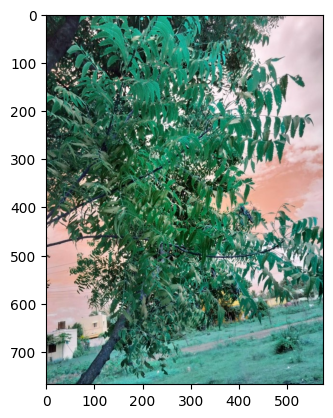

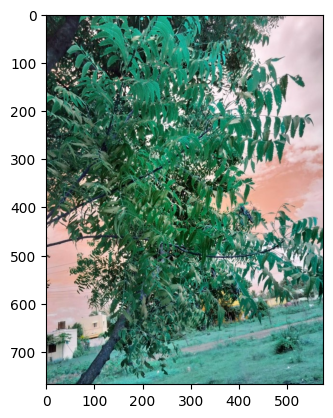

In [26]:
# plt.imshow(img_sam)
# plt.show()
# plt.imshow(img_arr_sam)
# plt.show()

In [5]:
x,_,y,_=train_test_split(x,y,test_size=0.9,random_state=42)

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train,x_val,y_train,y_val=train_test_split(x_train,y_train,test_size=0.1,random_state=42)

In [7]:
x_train.shape

(130, 768, 576, 3)

In [8]:
x_test.shape

(37, 768, 576, 3)

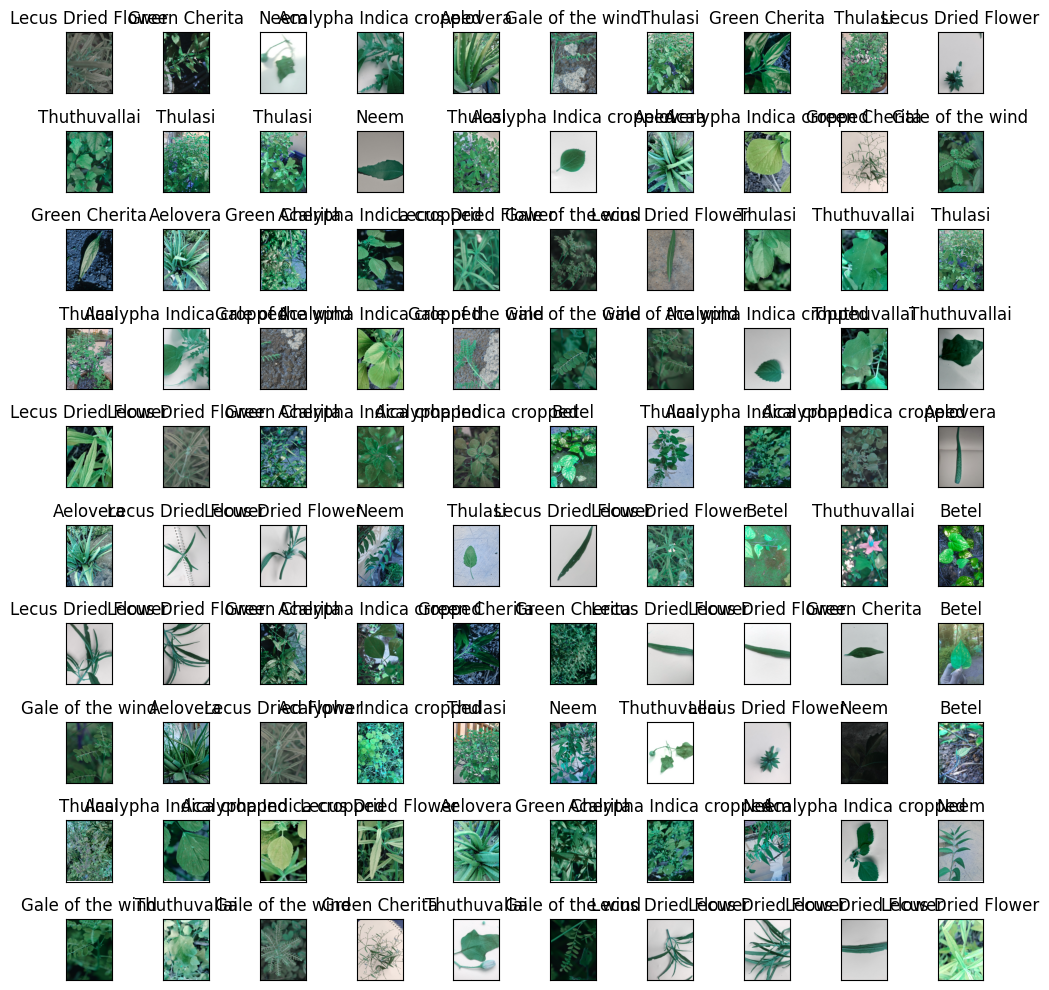

In [9]:
plt.rcParams["figure.figsize"] = (10,10)
fig,axes = plt.subplots(10,10)
for i,ax in enumerate(axes.flatten()):
  ax.imshow(x_train[i])
  ax.set_title(f'{y_train[i]}')
  ax.set_xticks([])
  ax.set_yticks([])
fig.tight_layout()

In [23]:
# scaler = StandardScaler()
# x_train=scaler.fit_transform(x_train)
# x_test=scaler.fit_transform(x_test)

In [10]:
x_train=x_train/255.0

In [14]:
print(x_train)

[[[[0.3254902  0.37254902 0.3254902 ]
   [0.30196078 0.34901961 0.30196078]
   [0.27843137 0.3372549  0.28235294]
   ...
   [0.43921569 0.50196078 0.45882353]
   [0.43921569 0.50196078 0.45882353]
   [0.43529412 0.50196078 0.45882353]]

  [[0.3372549  0.38431373 0.3372549 ]
   [0.31764706 0.36470588 0.31764706]
   [0.29411765 0.35294118 0.29803922]
   ...
   [0.44313725 0.50588235 0.4627451 ]
   [0.44313725 0.50588235 0.4627451 ]
   [0.43921569 0.50588235 0.4627451 ]]

  [[0.34901961 0.39607843 0.34901961]
   [0.32941176 0.37647059 0.32941176]
   [0.30196078 0.36078431 0.30588235]
   ...
   [0.44313725 0.50980392 0.45882353]
   [0.43921569 0.50588235 0.45490196]
   [0.43529412 0.50588235 0.45490196]]

  ...

  [[0.33333333 0.3372549  0.30196078]
   [0.33333333 0.3372549  0.30196078]
   [0.33333333 0.3372549  0.30196078]
   ...
   [0.20392157 0.20784314 0.2       ]
   [0.2        0.20392157 0.19607843]
   [0.2        0.20392157 0.19607843]]

  [[0.3372549  0.34117647 0.30588235]
   [0.3

In [11]:
x_test=x_test/255.0

In [12]:
x_val=x_val/255.0

In [21]:
train_x_preprocessed = preprocess_input(x_train)
val_x_preprocessed = preprocess_input(x_val)

In [22]:
train_x_preprocessed

array([[[[-103.6135098 , -116.40645098, -123.3545098 ],
         [-103.63703922, -116.42998039, -123.37803922],
         [-103.65664706, -116.4417451 , -123.40156863],
         ...,
         [-103.48017647, -116.27703922, -123.24078431],
         [-103.48017647, -116.27703922, -123.24078431],
         [-103.48017647, -116.27703922, -123.24470588]],

        [[-103.6017451 , -116.39468627, -123.3427451 ],
         [-103.62135294, -116.41429412, -123.36235294],
         [-103.64096078, -116.42605882, -123.38588235],
         ...,
         [-103.4762549 , -116.27311765, -123.23686275],
         [-103.4762549 , -116.27311765, -123.23686275],
         [-103.4762549 , -116.27311765, -123.24078431]],

        [[-103.58998039, -116.38292157, -123.33098039],
         [-103.60958824, -116.40252941, -123.35058824],
         [-103.63311765, -116.41821569, -123.37803922],
         ...,
         [-103.48017647, -116.26919608, -123.23686275],
         [-103.48409804, -116.27311765, -123.24078431],
  

### **Building Vgg16 model**

In [15]:
Vgg16_base_mdl = VGG16(weights='imagenet', include_top=False, input_shape=(x_train[0].shape),classes=9)
Vgg16_base_mdl.summary()

58889256/58889256 [==============================] - 0s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 768, 576, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 768, 576, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 768, 576, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 384, 288, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 384, 288, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 384, 288, 128)     147584    
                                                              

In [16]:
#changing the model in to non_trainable.
for layer in Vgg16_base_mdl.layers:
    layer.trainable = False

In [17]:
#model summary after Change non_trainable
Vgg16_base_mdl.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 768, 576, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 768, 576, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 768, 576, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 384, 288, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 384, 288, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 384, 288, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 192, 144, 128)     0     

### **Creating our Neural network**

In [18]:
X = layers.Flatten()(Vgg16_base_mdl.output)
X = layers.Dense(256,activation='relu')(X)
X = layers.Dropout(0.5)(X)
predictions = layers.Dense(9,activation='softmax')(X)
model=models.Model(inputs=Vgg16_base_mdl.input,outputs=predictions)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [23]:
model.fit(train_x_preprocessed,y_train,epochs=10,batch_size=5,validation_data=(val_x_preprocessed,y_val))

ValueError: ignored